In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import os

4 steps:

static beta and half-life (train data set)

rolling mean/std on spread

generate z score -> 

Trade mean reversion


Dataset preparation:

In [2]:
#merge price datasets on date column
print(os.getcwd())
soy = pd.read_csv("../data/daily_soybean_prices.csv")
corn = pd.read_csv("../data/daily_corn_prices.csv")

# Keep only what we need
soy = soy[["Date", "Close"]].rename(columns={"Close": "soy_price"})
corn = corn[["Date", "Close"]].rename(columns={"Close": "corn_price"})

# Convert dates
soy["Date"] = pd.to_datetime(soy["Date"])
corn["Date"] = pd.to_datetime(corn["Date"])

# Merge on common trading dates
prices = pd.merge(soy, corn, on="Date", how="inner")

# Sort and drop missing values
prices = prices.sort_values("Date").dropna()

prices.head()

c:\Users\Antonio\Documents\Github\Spring2026-TIC\6_mean_reversion_strategy


,Date,soy_price,corn_price
1,2005-01-03,537.25,201.75
2,2005-01-04,529.75,201.0
3,2005-01-05,534.0,201.5
4,2005-01-06,541.75,208.75
5,2005-01-07,551.75,206.75


In [3]:
# Clean price columns: remove commas and convert to numeric
prices["soy_price"] = (
    prices["soy_price"]
    .astype(str)
    .str.replace(",", "", regex=False)   # remove commas if they exist
    .str.strip()
)

prices["corn_price"] = (
    prices["corn_price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

prices["soy_price"] = pd.to_numeric(prices["soy_price"], errors="coerce")
prices["corn_price"] = pd.to_numeric(prices["corn_price"], errors="coerce")

In [4]:
# Take log of prices to stabilize variance
prices["log_soy"] = np.log(prices["soy_price"])
prices["log_corn"] = np.log(prices["corn_price"])

In [5]:
print(soy.head())
print(corn.head())
print(prices.head())
print(prices.dtypes)

        Date soy_price
0        NaT      ZS=F
1 2005-01-03    537.25
2 2005-01-04    529.75
3 2005-01-05     534.0
4 2005-01-06    541.75
        Date corn_price
0        NaT       ZC=F
1 2005-01-03     201.75
2 2005-01-04      201.0
3 2005-01-05      201.5
4 2005-01-06     208.75
        Date  soy_price  corn_price   log_soy  log_corn
1 2005-01-03     537.25      201.75  6.286464  5.307029
2 2005-01-04     529.75      201.00  6.272405  5.303305
3 2005-01-05     534.00      201.50  6.280396  5.305789
4 2005-01-06     541.75      208.75  6.294805  5.341137
5 2005-01-07     551.75      206.75  6.313095  5.331510
Date          datetime64[us]
soy_price            float64
corn_price           float64
log_soy              float64
log_corn             float64
dtype: object


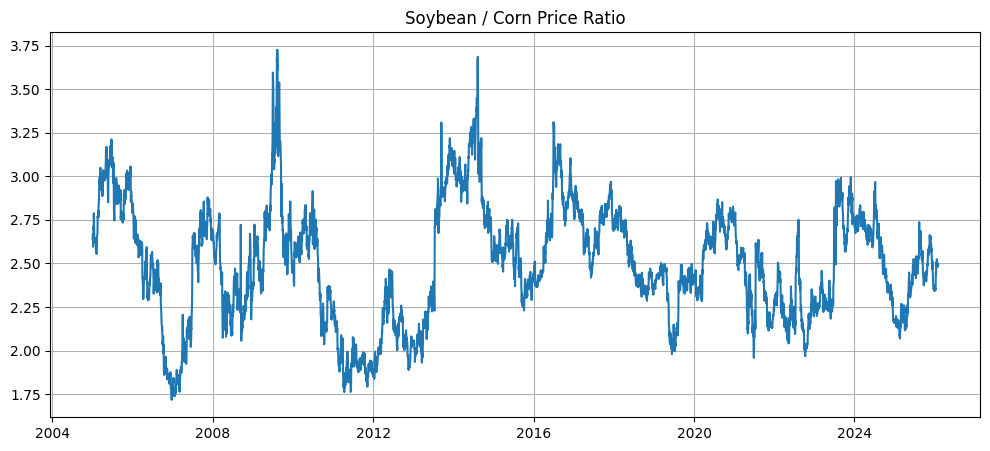

In [6]:
prices["ratio"] = prices["soy_price"] / prices["corn_price"]

plt.figure(figsize=(12,5))
plt.plot(prices["Date"], prices["ratio"])
plt.title("Soybean / Corn Price Ratio")
plt.grid(True)
plt.show()

Split data into trainig/test data set (6 months gap)

In [7]:
train_end = "2017-12-31"
gap_end   = "2018-06-30"

train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

ADF TEST:

In [8]:
X_train = sm.add_constant(train["log_corn"])
model = sm.OLS(train["log_soy"], X_train).fit()

alpha = model.params["const"]
beta = model.params["log_corn"]

print("alpha (train) =", alpha)
print("beta (train) =", beta)

# Step 3: construct spread using SAME alpha and beta
train["spread"] = train["log_soy"] - alpha - beta * train["log_corn"]
test["spread"]  = test["log_soy"]  - alpha - beta * test["log_corn"]


from statsmodels.tsa.stattools import adfuller

adf_result_train = adfuller(train["spread"].dropna())

print("ADF statistic (train):", adf_result_train[0])
print("p-value (train):", adf_result_train[1])
print("Critical values (train):", adf_result_train[4])

alpha (train) = 2.456400590267233
beta (train) = 0.7429491347666052
ADF statistic (train): -2.93847116435615
p-value (train): 0.04105374861819684
Critical values (train): {'1%': np.float64(-3.432353811104443), '5%': np.float64(-2.862425364403165), '10%': np.float64(-2.567241298246627)}


This was performed on all data, left here so we can compare results:

Hurst Exponent test:

In [9]:
# Hurst exponent on TRAIN spread
def hurst(ts):
    ts = np.array(ts)
    lags = range(2, 100)

    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]

    poly = np.polyfit(np.log(lags), np.log(tau), 1)

    return poly[0]

H_spread_train = hurst(train["spread"].dropna())

print("Hurst exponent (train spread):", H_spread_train)


Hurst exponent (train spread): 0.44964791863985654


Variance Ratio test:

In [10]:
# Variance Ratio test on TRAIN spread
from arch.unitroot import VarianceRatio

vr_train = VarianceRatio(train["spread"].dropna(), lags=5)

print(vr_train.summary())

     Variance-Ratio Test Results     
Test Statistic                 -0.615
P-value                         0.538
Lags                                5
-------------------------------------

Computed with overlapping blocks (de-biased)


Johansen test:


In [11]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# use only the training sample
joh_data = train[["log_soy", "log_corn"]].dropna()

jres = coint_johansen(joh_data, det_order=0, k_ar_diff=1)

print("Trace stats:", jres.lr1)
print("Critical values (90%, 95%, 99%):")
print(jres.cvt)


jres.lr1[0] > jres.cvt[0, 2] 


Trace stats: [22.59261929  5.17515883]
Critical values (90%, 95%, 99%):
[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


np.True_

Fail to teject co integration at 99% CL : now: extract  eigenvectors 

In [12]:
print("Eigenvectors:")
print(jres.evec)

vec = jres.evec[:, 0]
vec = vec / vec[0]
print(vec)

Eigenvectors:
[[ 7.83829725  0.14204203]
 [-5.87465586  2.70504738]]
[ 1.         -0.74948113]


Construct Johansen spread:

In [13]:
train["spread_joh"] = (
    vec[0] * train["log_soy"] +
    vec[1] * train["log_corn"]
)

test["spread_joh"] = (
    vec[0] * test["log_soy"] +
    vec[1] * test["log_corn"]
)

In [14]:
from statsmodels.tsa.stattools import adfuller

adf_joh = adfuller(train["spread_joh"].dropna())

print("ADF stat (Johansen spread):", adf_joh[0])
print("p-value:", adf_joh[1])
print("Critical values:", adf_joh[4])

ADF stat (Johansen spread): -2.94388629298885
p-value: 0.04047747387000796
Critical values: {'1%': np.float64(-3.432353811104443), '5%': np.float64(-2.862425364403165), '10%': np.float64(-2.567241298246627)}


Computing half-life and z-score:

In [15]:
def half_life(spread):
    spread = spread.dropna()

    lagged = spread.shift(1)
    delta = spread - lagged

    df = pd.concat([lagged, delta], axis=1).dropna()
    df.columns = ["lagged", "delta"]

    X = sm.add_constant(df["lagged"])
    model = sm.OLS(df["delta"], X).fit()

    phi = model.params["lagged"]

    hl = -np.log(2) / phi if phi < 0 else np.nan
    return hl, model

hl_joh, _ = half_life(train["spread_joh"])
print("Half-life (Johansen spread):", hl_joh)

Half-life (Johansen spread): 98.15819926274351


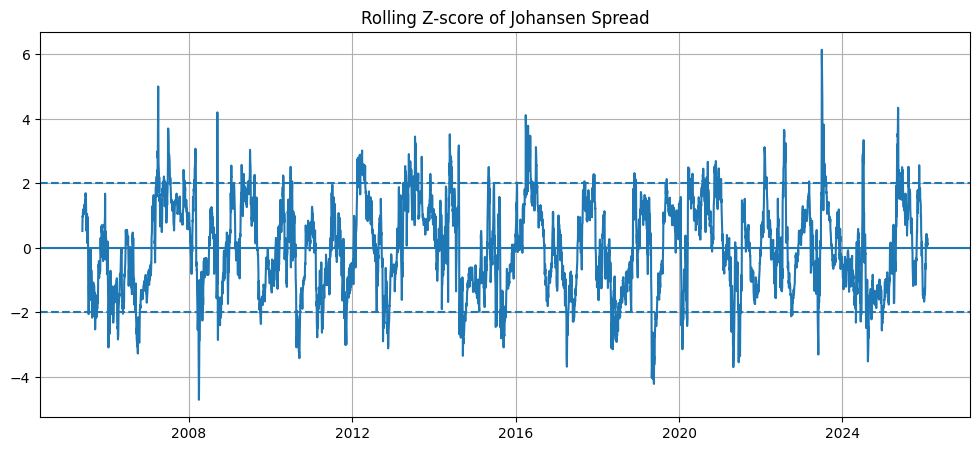

In [16]:
prices["spread_joh"] = (
    vec[0] * prices["log_soy"] +
    vec[1] * prices["log_corn"]
)

window_z = max(2, int(round(hl_joh)))

prices["spread_mean_roll"] = prices["spread_joh"].rolling(window_z).mean().shift(1)
prices["spread_std_roll"]  = prices["spread_joh"].rolling(window_z).std().shift(1)

prices["zscore_joh"] = (
    (prices["spread_joh"] - prices["spread_mean_roll"]) / prices["spread_std_roll"]
)
prices.loc[prices["spread_std_roll"] == 0, "zscore_joh"] = np.nan
train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

plt.figure(figsize=(12,5))
plt.plot(prices["Date"], prices["zscore_joh"])
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0)
plt.title("Rolling Z-score of Johansen Spread")
plt.grid(True)
plt.show()

Testing performance for different grids:

In [17]:
prices["ret_soy"] = prices["log_soy"].diff()
prices["ret_corn"] = prices["log_corn"].diff()
hedge_ratio = -vec[1]
prices["spread_ret"] = prices["ret_soy"] - hedge_ratio * prices["ret_corn"]

entry_grid = [1.5, 2.0, 2.5, 3.0]
exit_z = 0

# split indicator
prices["sample"] = np.where(prices["Date"] <= pd.to_datetime(train_end), "train",
                     np.where(prices["Date"] > pd.to_datetime(gap_end), "test", "gap"))

results = []

for entry_z in entry_grid:
    positions = []
    pos = 0

    for z in prices["zscore_joh"]:
        if np.isnan(z):
            positions.append(0)
            continue

        if pos == 0:
            if z < -entry_z:
                pos = 1      # long spread
            elif z > entry_z:
                pos = -1     # short spread

        elif pos == 1:
            if z >= -exit_z:
                pos = 0

        elif pos == -1:
            if z <= exit_z:
                pos = 0

        positions.append(pos)

    prices[f"position_{entry_z}"] = positions
    prices[f"strategy_ret_{entry_z}"] = prices[f"position_{entry_z}"].shift(1) * prices["spread_ret"]

    for sample_name in ["train", "test"]:
        sample = prices[prices["sample"] == sample_name].copy()
        ret = sample[f"strategy_ret_{entry_z}"].dropna()

        mean_ret = ret.mean()
        std_ret = ret.std()
        sharpe = np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan
        cum_ret = ret.sum()
        n_trades = sample[f"position_{entry_z}"].diff().abs().fillna(0).sum() / 2

        results.append({
            "entry_z": entry_z,
            "sample": sample_name,
            "mean_daily_ret": mean_ret,
            "std_daily_ret": std_ret,
            "sharpe": sharpe,
            "cum_log_ret": cum_ret,
            "n_trades": n_trades
        })

results_df = pd.DataFrame(results)
print(results_df)

   entry_z sample  mean_daily_ret  std_daily_ret    sharpe  cum_log_ret  \
0      1.5  train        0.000151       0.012962  0.184394     0.492488   
1      1.5   test        0.000402       0.010603  0.602450     0.766932   
2      2.0  train        0.000018       0.012707  0.022174     0.058058   
3      2.0   test        0.000298       0.009876  0.478412     0.567276   
4      2.5  train        0.000039       0.012143  0.050953     0.127491   
5      2.5   test        0.000244       0.009069  0.427230     0.465187   
6      3.0  train        0.000149       0.010580  0.223897     0.488107   
7      3.0   test        0.000238       0.008724  0.432190     0.452682   

   n_trades  
0      47.0  
1      30.5  
2      31.0  
3      21.5  
4      24.0  
5      14.5  
6      18.0  
7      11.5  


In [18]:
print(results_df.pivot(index="entry_z", columns="sample", values="sharpe"))
print(results_df.pivot(index="entry_z", columns="sample", values="cum_log_ret"))
print(results_df.pivot(index="entry_z", columns="sample", values="n_trades"))

sample       test     train
entry_z                    
1.5      0.602450  0.184394
2.0      0.478412  0.022174
2.5      0.427230  0.050953
3.0      0.432190  0.223897
sample       test     train
entry_z                    
1.5      0.766932  0.492488
2.0      0.567276  0.058058
2.5      0.465187  0.127491
3.0      0.452682  0.488107
sample   test  train
entry_z             
1.5      30.5   47.0
2.0      21.5   31.0
2.5      14.5   24.0
3.0      11.5   18.0


Based on this result: use entry z = 1.5

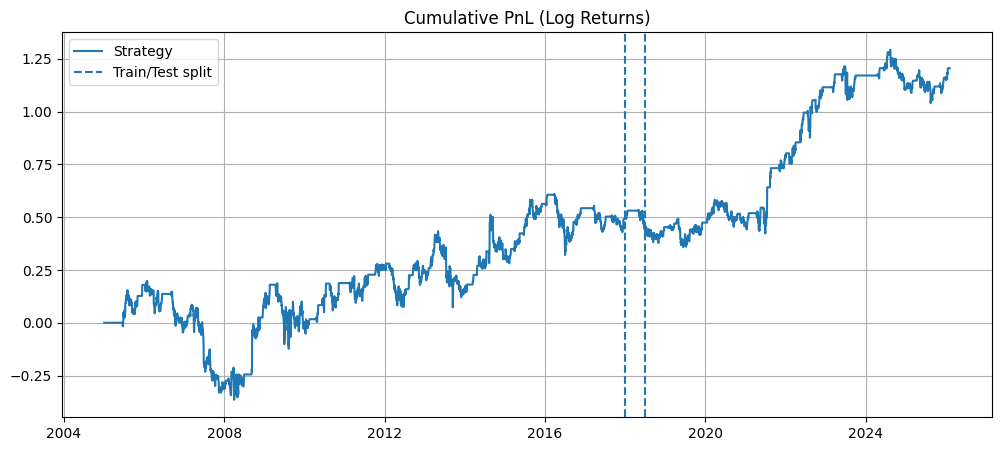

In [19]:
prices["strategy_ret"] = prices["strategy_ret_1.5"]
prices["cum_pnl"] = prices["strategy_ret"].cumsum()

plt.figure(figsize=(12,5))
plt.plot(prices["Date"], prices["cum_pnl"], label="Strategy")

plt.axvline(pd.to_datetime(train_end), linestyle="--", label="Train/Test split")
plt.axvline(pd.to_datetime(gap_end), linestyle="--")

plt.title("Cumulative PnL (Log Returns)")
plt.legend()
plt.grid(True)
plt.show()

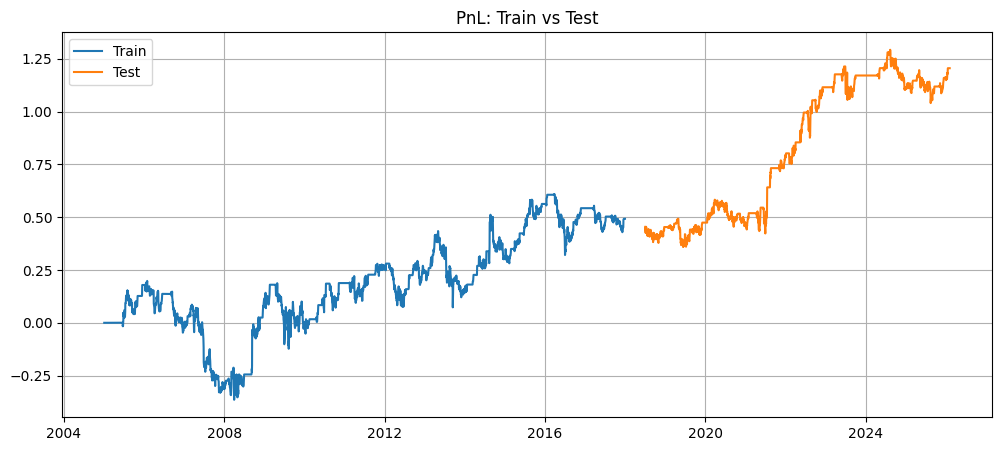

In [20]:
prices["strategy_ret"] = prices["strategy_ret_1.5"]
prices["cum_pnl"] = prices["strategy_ret"].cumsum()

train = prices[prices["Date"] <= train_end].copy()
test  = prices[prices["Date"] > gap_end].copy()

plt.figure(figsize=(12,5))
plt.plot(train["Date"], train["cum_pnl"], label="Train")
plt.plot(test["Date"], test["cum_pnl"], label="Test")
plt.title("PnL: Train vs Test")
plt.legend()
plt.grid(True)
plt.show()

Maximum drawdown: -0.4302322826073982
Date of maximum drawdown: 2008-04-01 00:00:00


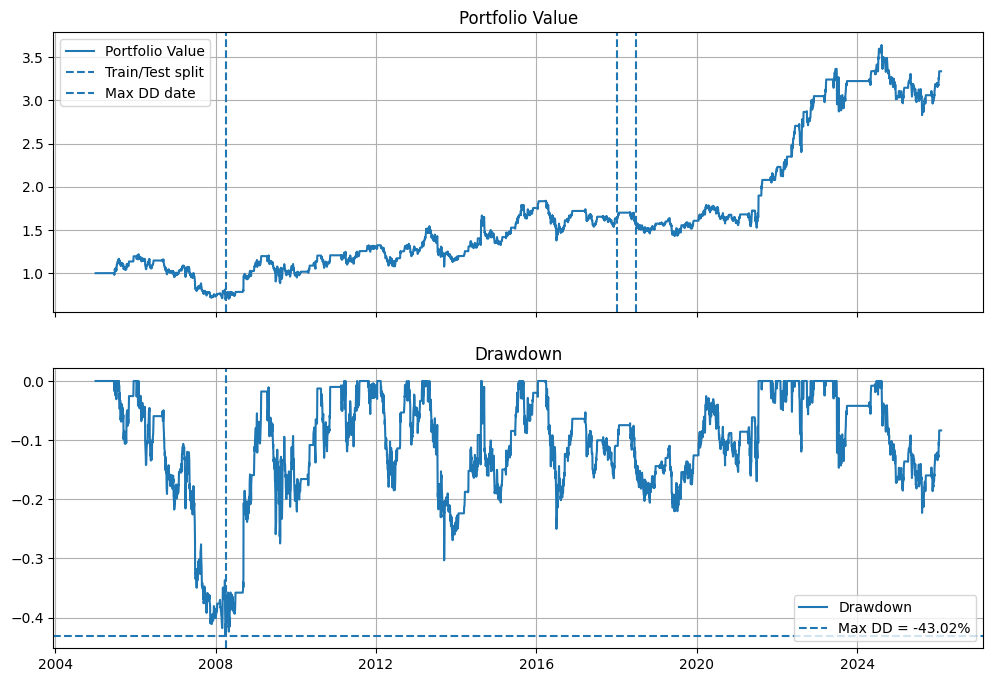

In [21]:
prices["strategy_ret"] = prices["strategy_ret_1.5"]   # or whichever threshold you chose

prices["cum_log_ret"] = prices["strategy_ret"].cumsum()
prices["portfolio_value"] = np.exp(prices["cum_log_ret"])

prices["running_max"] = prices["portfolio_value"].cummax()
prices["drawdown"] = prices["portfolio_value"] / prices["running_max"] - 1

max_dd = prices["drawdown"].min()
max_dd_date = prices.loc[prices["drawdown"].idxmin(), "Date"]

print("Maximum drawdown:", max_dd)
print("Date of maximum drawdown:", max_dd_date)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

ax1.plot(prices["Date"], prices["portfolio_value"], label="Portfolio Value")
ax1.axvline(pd.to_datetime(train_end), linestyle="--", label="Train/Test split")
ax1.axvline(pd.to_datetime(gap_end), linestyle="--")
ax1.set_title("Portfolio Value")
ax1.axvline(max_dd_date, linestyle="--", label="Max DD date")
ax1.legend()
ax1.grid(True)

ax2.plot(prices["Date"], prices["drawdown"], label="Drawdown")
ax2.axhline(max_dd, linestyle="--", label=f"Max DD = {max_dd:.2%}")
ax2.axvline(max_dd_date, linestyle="--")
ax2.set_title("Drawdown")
ax2.legend()
ax2.grid(True)

plt.show()

Kalmann Filter estimates


In [22]:
from pykalman import KalmanFilter

In [23]:
def kalman_spread(df, delta, alpha_init, beta_init, obs_cov=0.01):
    y = df["log_soy"].values
    x = df["log_corn"].values

    obs_mat = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis]

    trans_cov = delta / (1 - delta) * np.eye(2)

    kf = KalmanFilter(
        n_dim_obs=1,
        n_dim_state=2,
        initial_state_mean=np.array([beta_init, alpha_init]),
        initial_state_covariance=0.1 * np.eye(2),
        transition_matrices=np.eye(2),
        observation_matrices=obs_mat,
        observation_covariance=obs_cov,
        transition_covariance=trans_cov
    )

    state_means, state_covs = kf.filter(y)

    out = df.copy()
    out["beta_kf"] = state_means[:, 0]
    out["alpha_kf"] = state_means[:, 1]

    out["spread_kf"] = (
        out["log_soy"]
        - out["beta_kf"] * out["log_corn"]
        - out["alpha_kf"]
    )

    return out

alpha_init = alpha      # from your OLS
beta_init = beta

In [24]:
def kalman_strategy(df, hl_window, entry_z=1.5, exit_z=0):
    out = df.copy()

    window = int(round(hl_window))

    out["spread_kf_mean"] = out["spread_kf"].rolling(window).mean()
    out["spread_kf_std"] = out["spread_kf"].rolling(window).std()

    out["zscore_kf"] = (
        (out["spread_kf"] - out["spread_kf_mean"]) / out["spread_kf_std"]
    )

    positions = []
    pos = 0

    for z in out["zscore_kf"]:
        if np.isnan(z):
            positions.append(0)
            continue

        if pos == 0:
            if z < -entry_z:
                pos = 1
            elif z > entry_z:
                pos = -1

        elif pos == 1:
            if z >= -exit_z:
                pos = 0

        elif pos == -1:
            if z <= exit_z:
                pos = 0

        positions.append(pos)

    out["position_kf"] = positions

    out["ret_soy"] = out["log_soy"].diff()
    out["ret_corn"] = out["log_corn"].diff()

    out["spread_ret_kf"] = (
        out["ret_soy"] - out["beta_kf"].shift(1) * out["ret_corn"]
    )

    out["strategy_ret_kf"] = (
        out["position_kf"].shift(1) * out["spread_ret_kf"]
    )

    return out

def strategy_stats(df, ret_col="strategy_ret_kf"):
    ret = df[ret_col].dropna()

    mean_ret = ret.mean()
    std_ret = ret.std()
    sharpe = np.sqrt(252) * mean_ret / std_ret if std_ret > 0 else np.nan
    cum_log_ret = ret.sum()

    return {
        "mean_daily_ret": mean_ret,
        "std_daily_ret": std_ret,
        "sharpe": sharpe,
        "cum_log_ret": cum_log_ret
    }

Grid search on delta and obs covariance

In [25]:
delta_grid = [1e-7, 1e-6, 1e-5, 1e-4]
obs_grid = [0.001, 0.01, 0.1, 1.0]

results = []

for delta in delta_grid:
    for obs_cov in obs_grid:
        train_kf = kalman_spread(
            train,
            delta=delta,
            alpha_init=alpha_init,
            beta_init=beta_init,
            obs_cov=obs_cov
        )

        train_kf = kalman_strategy(train_kf, hl_window=hl_joh, entry_z=1.5, exit_z=0)
        stats = strategy_stats(train_kf, ret_col="strategy_ret_kf")

        stats["delta"] = delta
        stats["obs_cov"] = obs_cov
        results.append(stats)

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df)

    mean_daily_ret  std_daily_ret    sharpe  cum_log_ret         delta  \
4         0.000496       0.009507  0.827970     1.621961  1.000000e-06   
14        0.000499       0.010022  0.790188     1.631738  1.000000e-04   
9         0.000484       0.009814  0.783536     1.584549  1.000000e-05   
10        0.000439       0.010242  0.680683     1.436481  1.000000e-05   
5         0.000409       0.009943  0.652869     1.337527  1.000000e-06   
0         0.000402       0.009848  0.648585     1.316100  1.000000e-07   
15        0.000385       0.010200  0.599718     1.260482  1.000000e-04   
13        0.000250       0.009109  0.435934     0.818221  1.000000e-04   
8         0.000236       0.008943  0.418287     0.770811  1.000000e-05   
6         0.000215       0.011110  0.307810     0.704632  1.000000e-06   
1         0.000198       0.010961  0.287202     0.648642  1.000000e-07   
11        0.000193       0.011732  0.261535     0.632258  1.000000e-05   
2         0.000064       0.011807  0.0

In [33]:
best_delta = results_df.iloc[0]["delta"]
best_obs_cov = results_df.iloc[0]["obs_cov"]

print("Best delta:", best_delta)
print("Best obs_cov:", best_obs_cov)

Best delta: 1e-06
Best obs_cov: 0.001


In [40]:
prices_kf = kalman_spread(
    prices,
    delta=best_delta,
    alpha_init=alpha_init,
    beta_init=beta_init,
    obs_cov=best_obs_cov
)

prices_kf = kalman_strategy(prices_kf, hl_window=hl_joh, entry_z=1.5, exit_z=0)

train_kf = prices_kf[prices_kf["Date"] <= train_end].copy()
test_kf  = prices_kf[prices_kf["Date"] > gap_end].copy()

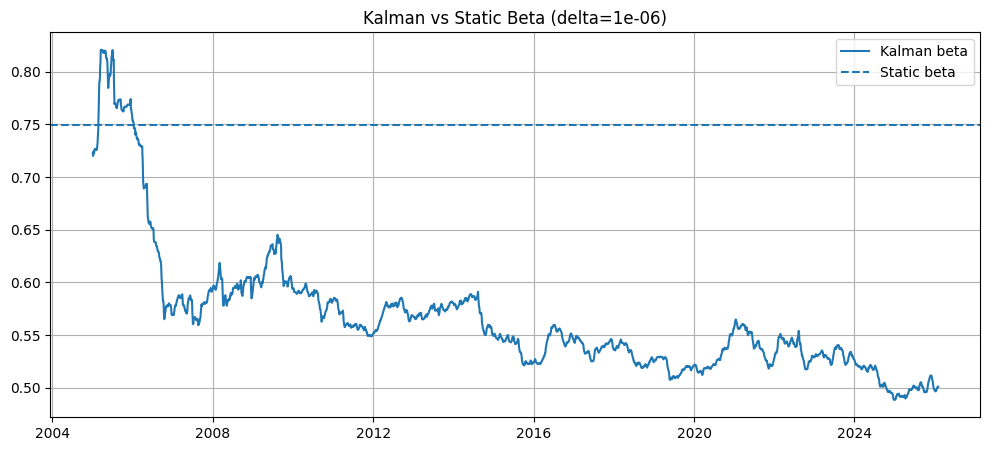

In [41]:
plt.figure(figsize=(12,5))

# Kalman beta (time-varying)
plt.plot(prices_kf["Date"], prices_kf["beta_kf"], label="Kalman beta")

# Static beta (constant line)
plt.axhline(y=hedge_ratio, linestyle="--", label="Static beta")

plt.title(f"Kalman vs Static Beta (delta={best_delta})")
plt.legend()
plt.grid(True)
plt.show()

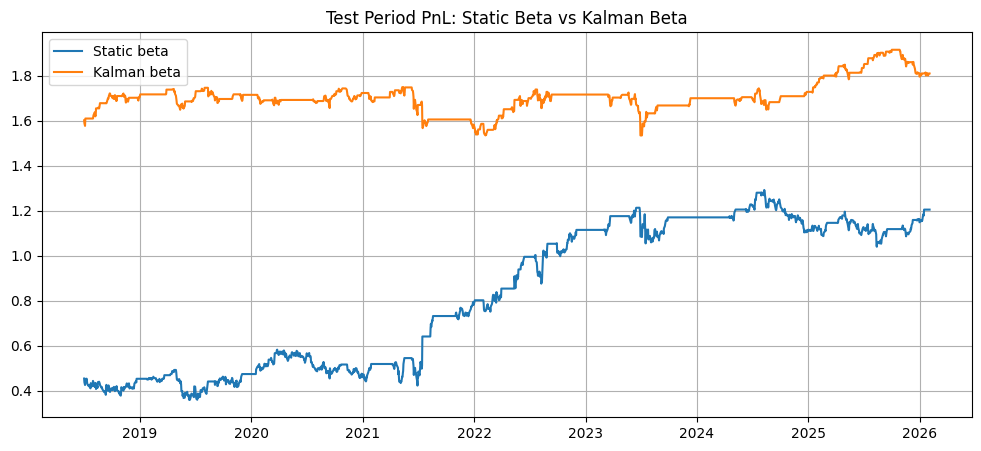

In [42]:
# Kalman cumulative PnL
prices_kf["cum_pnl_kf"] = prices_kf["strategy_ret_kf"].cumsum()

# Keep only test period
test_static = prices[prices["Date"] > gap_end].copy()
test_kf = prices_kf[prices_kf["Date"] > gap_end].copy()

plt.figure(figsize=(12,5))
plt.plot(test_static["Date"], test_static["cum_pnl"], label="Static beta")
plt.plot(test_kf["Date"], test_kf["cum_pnl_kf"], label="Kalman beta")

plt.title("Test Period PnL: Static Beta vs Kalman Beta")
plt.legend()
plt.grid(True)
plt.show()

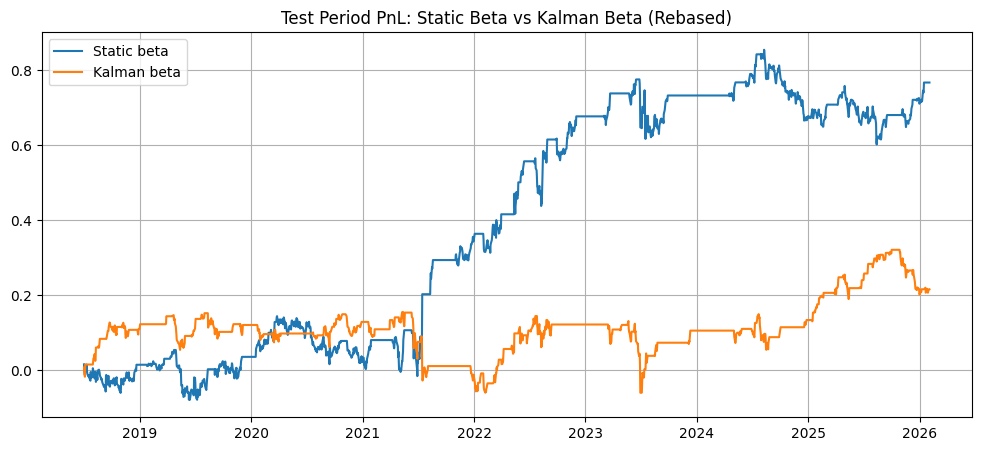

In [43]:
test_static["cum_pnl_test"] = test_static["strategy_ret"].cumsum()
test_kf["cum_pnl_kf_test"] = test_kf["strategy_ret_kf"].cumsum()

plt.figure(figsize=(12,5))
plt.plot(test_static["Date"], test_static["cum_pnl_test"], label="Static beta")
plt.plot(test_kf["Date"], test_kf["cum_pnl_kf_test"], label="Kalman beta")

plt.title("Test Period PnL: Static Beta vs Kalman Beta (Rebased)")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
print([col for col in prices.columns if "strategy" in col])

['strategy_ret_1.5', 'strategy_ret_2.0', 'strategy_ret_2.5', 'strategy_ret_3.0', 'strategy_ret', 'strategy_ret_static']


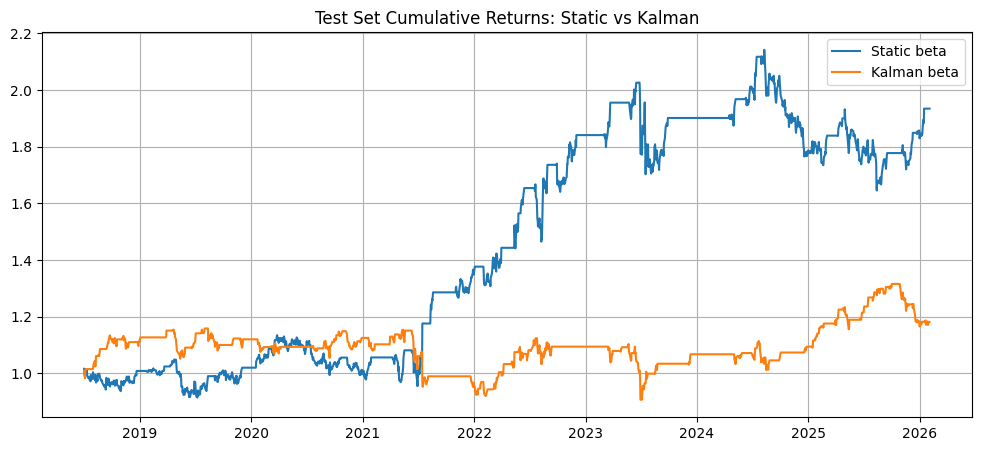

In [45]:
# Keep only test period
# FIX: use correct column name
prices["strategy_ret_static"] = prices["strategy_ret_1.5"]

# Test split
test_static = prices[prices["Date"] > pd.to_datetime(gap_end)].copy()
test_kf = prices_kf[prices_kf["Date"] > pd.to_datetime(gap_end)].copy()

# Cum returns
test_static["cum_ret_static"] = (1 + test_static["strategy_ret_static"].fillna(0)).cumprod()
test_kf["cum_ret_kf"] = (1 + test_kf["strategy_ret_kf"].fillna(0)).cumprod()

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_static["Date"], test_static["cum_ret_static"], label="Static beta")
plt.plot(test_kf["Date"], test_kf["cum_ret_kf"], label="Kalman beta")
plt.title("Test Set Cumulative Returns: Static vs Kalman")
plt.legend()
plt.grid(True)
plt.show()